# ROM1 Base-Excitation Bifurcation Study


Project root: D:\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam
Joblib available: True
First natural frequency [Hz]: 5.69543112994812
Electromechanical coupling: 0.00036615349431026213
Cp_scalar [nF]: 10.894621964621964


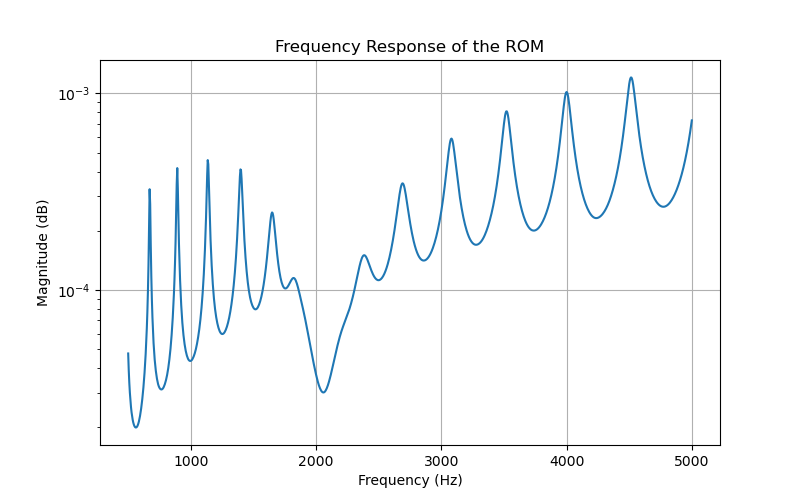

In [82]:
import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

try:
    from joblib import Parallel, delayed
    HAS_JOBLIB = True
except ImportError:
    HAS_JOBLIB = False

# Ensure workspace root containing Modeling/ is first on sys.path.
cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / 'Modeling').is_dir()), None)
if project_root is None:
    raise RuntimeError('Could not find project root containing Modeling/.')
sys.path.insert(0, str(project_root))

from Modeling.models.beam_properties import PiezoBeamParams
import Modeling.models.ROM1 as rom1_module
importlib.reload(rom1_module)
ROM = rom1_module.ROM

print(f'Project root: {project_root}')
print(f'Joblib available: {HAS_JOBLIB}')
params_rom = PiezoBeamParams(hp=0.252e-3, hs=0.51e-3)


N_modes = 20
rom = ROM(params=params_rom, N=N_modes, modal_damping_ratios=np.array([0.0065] * N_modes))

print('First natural frequency [Hz]:', rom.omega[0] / (2 * np.pi))
print('Electromechanical coupling:', (rom.p.theta_mech * rom.Gamma)[0, 0])
print('Cp_scalar [nF]:', rom.p.Cp_scalar * 1e9)

import pandas as pd
from scipy.signal import chirp
amp = 50
f0 = 500
f = 5000
K_p = 0.015
R_c = 1000
K_p = 0.015
K_i = 1820
K_c = 3e10

rtol = 1e-7
atol = 1e-9

ode_sys = rom.build_ode_system(
    j_exc=30,
    R_c=R_c,
    K_p=K_p,
    K_i=K_i,
    K_c=K_c,
)
freq_resp = rom.frequency_response_fe3(ode_sys, w= np.linspace(f0 , f, 1000)*2*np.pi)
x_eval  = np.linspace(0, rom.p.L_b, 100)
# print('Sweep points:', len(amps))
plt.figure(figsize=(8, 5))
plt.semilogy(freq_resp['freq_hz'], np.mean(np.abs(freq_resp['veloc']), axis=0), label='Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Frequency Response of the ROM')
plt.grid()
# plt.legend()
plt.show()

# %matplotlib widget

In [11]:
# # Single simulation 
# f0= 3000
# f = 3100
# n_periods_total = 5000
# n_periods_keep = 4000
# points_per_period = 100
# T = 1 / f
# dt = T / points_per_period
# t_end  = n_periods_total * T
# t_eval = np.arange(0, t_end, dt)
# def v_exc(t):
#     t1 = t_end / 5
#     t = np.asarray(t)
#     out = amp * np.cos(2 * np.pi * f * t)
#     out = np.where(t < t1, amp * chirp(t, f0=f0, f1=f, t1=t1, method="linear"), out)
#     return out

# # def v_exc(t):
# #     return amp * chirp(t, f0=f0, f1=f, t1=t_end, method="linear")

# r = rom.run_time_sim(
#     v_exc=v_exc,
#     j_exc=30,
#     R_c=R_c,
#     K_p=K_p,
#     K_i=K_i,
#     K_c=K_c,
#     t_end=t_end,
#     t_eval=t_eval,
#     x_eval=x_eval,
#     rtol=rtol,
#     atol=atol,
#     )

In [12]:
# Stroboscopic sampling for Poincaré map.
def make_fe3_rhs(ode_sys):
    """Convert FE3 second-order form to first-order for solve_ivp."""
    M = ode_sys.M
    n = M.shape[0]
    M_diag = np.diag(M)
    is_diagonal = np.allclose(M, np.diag(M_diag), rtol=1e-12, atol=1e-15)

    if is_diagonal:
        if np.any(np.isclose(M_diag, 0.0)):
            raise ValueError("Mass matrix is diagonal but has near-zero diagonal entries.")
        M_inv_diag = 1.0 / M_diag
        print("RHS solve mode: diagonal mass matrix (elementwise divide)")
    else:
        print("RHS solve mode: dense mass matrix (np.linalg.solve)")

    def rhs(t, y):
        x = y[:n]
        x_dot = y[n:]
        residual = ode_sys.f_ext(t) - ode_sys.C @ x_dot - ode_sys.f_int(x)

        if is_diagonal:
            x_ddot = M_inv_diag * residual
        else:
            x_ddot = np.linalg.solve(M, residual)

        return np.concatenate([x_dot, x_ddot])

    return rhs


def stroboscopic_sample(t, response, points_per_period, n_periods_keep):
    """Return the steady-state stroboscopic samples for a periodic response."""
    response = np.asarray(response)
    strobe_indices = np.arange(0, len(t), points_per_period)
    t_strobe = t[strobe_indices]

    if response.ndim == 1:
        response_strobe = response[strobe_indices]
    else:
        response_strobe = response[..., strobe_indices]

    # Discard transient for the Poincaré map.
    return {
        "t_strobe": t_strobe[-n_periods_keep:],
        "response_poincare": response_strobe[..., -n_periods_keep:],
    }



def stroboscopic_sample_x_and_xdot(t, eta, eta_dot, z, v, points_per_period, n_periods_keep):
    """Return separate stroboscopic samples for displacement and velocity."""
    eta_sample = stroboscopic_sample(t, eta, points_per_period, n_periods_keep)
    eta_dot_sample = stroboscopic_sample(t, eta_dot, points_per_period, n_periods_keep)
    z_sample = stroboscopic_sample(t, z, points_per_period, n_periods_keep)
    v_sample = stroboscopic_sample(t, v, points_per_period, n_periods_keep)
    return {
        "t_strobe": eta_sample["t_strobe"],
        "eta_poincare": eta_sample["response_poincare"],
        "eta_dot_poincare": eta_dot_sample["response_poincare"],
        "z_poincare": z_sample["response_poincare"],
        "v_poincare": v_sample["response_poincare"],
    }



In [13]:
# Amplitude sweep
amps = np.linspace(0.05, 0.4, 4)*125
import os
import uuid
from pathlib import Path

results_dir = Path("results_amp")
results_dir.mkdir(exist_ok=True)

def single_simulation(amp):
    f0 = 2900
    f = 3200
    n_periods_total = 100000
    n_periods_keep = 4000
    points_per_period = 100
    T = 1 / f
    dt = T / points_per_period
    t_end = n_periods_total * T
    t_eval = np.arange(0, t_end, dt)

    def v_exc(t):
        return amp * chirp(t, f0=f0, f1=f, t1=t_end, method="linear")

    out = rom.run_time_sim(
        v_exc=v_exc,
        j_exc=30,
        R_c=R_c,
        K_p=K_p,
        K_i=K_i,
        K_c=K_c,
        t_end=t_end,
        t_eval=t_eval,
        x_eval=x_eval,
        rtol=rtol,
        atol=atol,
    )

    eta = out["eta"]
    eta_dot = out["eta_dot"]
    z = out["z"]
    v = out["v"]
    t = out["t"]

    # strobe = stroboscopic_sample_x_and_xdot(t, eta, eta_dot, z, v, points_per_period, n_periods_keep)

    arrays_to_save = {
        "t": t,
        "veloc": out["veloc"],
        "eta": eta,
        "eta_dot": eta_dot,
        "z": z,
        "v": v,
        "freq": out["freq"],
        "FRF": out["FRF"],
        "Y": out["Y"],
        # "t_strobe": strobe["t_strobe"],
        # "eta_poincare": strobe["eta_poincare"],
        # "eta_dot_poincare": strobe["eta_dot_poincare"],
        # "z_poincare": strobe["z_poincare"],
        # "v_poincare": strobe["v_poincare"],
    }

    fname = results_dir / f"res_amp_{int(round(100*amp))}_{uuid.uuid4().hex}.npz"
    try:
        np.savez_compressed(fname, **arrays_to_save)
    except Exception as e:
        print("Error saving result file:", e)
        raise

    return {"amp": float(amp), "file": str(fname)}

# Run workers (they now return small metadata + filename)
results_meta = Parallel(n_jobs=len(amps), verbose=12)(
    delayed(single_simulation)(a) for a in amps
)

# Helper to load saved .npz
def load_result_file(path):
    with np.load(path, allow_pickle=True) as data:
        return {k: data[k] for k in data.files}

# Build full in-memory results list only when/if needed:
results_amp = []
for m in results_meta:
    d = load_result_file(m["file"])
    d["amp"] = m["amp"]
    d["file"] = m["file"]
    results_amp.append(d)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed: 37.6min
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed: 38.8min remaining: 38.8min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed: 42.7min finished


In [ ]:
# import re
# from pathlib import Path

# def rename_results_sequential(results_meta, results_dir):
#     pat = re.compile(r"res_amp_(\d+)_(\d+)\.npz$")
#     results_dir = Path(results_dir)
#     for m in results_meta:
#         old = Path(m["file"])
#         amp_int = int(round(100 * float(m["amp"])))
#         # find max existing index for this amp
#         existing = list(results_dir.glob(f"res_amp_{amp_int}_*.npz"))
#         max_idx = 0
#         for p in existing:
#             mo = pat.match(p.name)
#             if mo and int(mo.group(1)) == amp_int:
#                 max_idx = max(max_idx, int(mo.group(2)))
#         next_idx = max_idx + 1
#         new_name = results_dir / f"res_amp_{amp_int}_{next_idx:03d}.npz"
#         while new_name.exists():
#             next_idx += 1
#             new_name = results_dir / f"res_amp_{amp_int}_{next_idx:03d}.npz"
#         old.replace(new_name)     # atomic rename
#         m["file"] = str(new_name) # update metadata
#     return results_meta

# # call it
# results_dir = "results_amp"
# results_meta = rename_results_sequential(results_meta, results_dir)
import re, numpy as np
from pathlib import Path

def make_lazy_results(results_meta=None, results_dir="results_amp"):
    pat = re.compile(r"res_amp_(\d+)_(\d+)\.npz")
    if results_meta is None:
        files = sorted(Path(results_dir).glob("res_amp_*.npz"))
        results_meta = []
        for p in files:
            m = pat.match(p.name)
            if m:
                results_meta.append({"amp": int(m.group(1))/100.0, "file": str(p)})
    return [{"amp": float(m["amp"]), "file": m["file"], "loader": (lambda f=m["file"]: np.load(f, allow_pickle=True))} for m in results_meta]

results_amp = make_lazy_results(globals().get("results_meta"))
print(f"Prepared {len(results_amp)} lazy result handle(s). Call r['loader']() to access arrays.")

Loaded 4 result(s).


In [71]:
results_meta

[{'amp': 6.25, 'file': 'results_amp\\res_amp_625_001.npz'},
 {'amp': 20.833333333333336, 'file': 'results_amp\\res_amp_2083_001.npz'},
 {'amp': 35.41666666666667, 'file': 'results_amp\\res_amp_3542_001.npz'},
 {'amp': 50.0, 'file': 'results_amp\\res_amp_5000_001.npz'}]

(1e-05, 0.01)

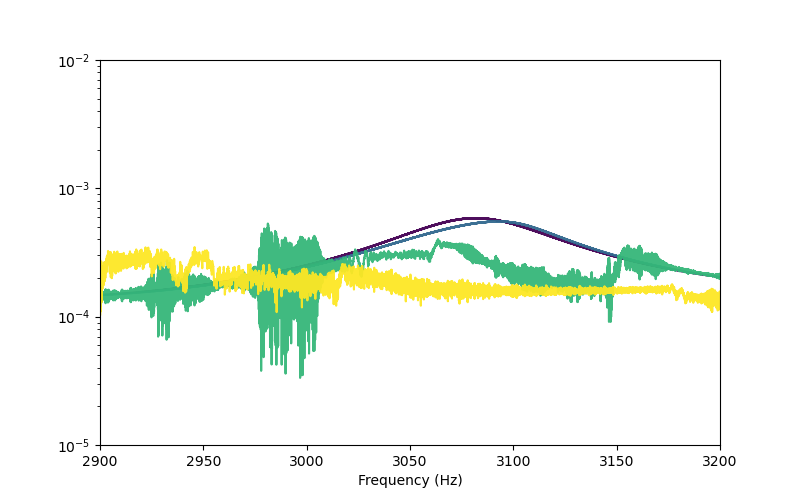

In [81]:
# =========================
# Bifurcation plot
# =========================
plt.figure(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(results_amp)))
for idx, r in enumerate(results_amp):
    plt.semilogy(r["freq"], np.abs(r["FRF"]),color=colors[idx],  alpha=0.95, label=f'A={r["amp"]:.2f}')
plt.xlabel('Frequency (Hz)')
plt.xlim(2900,  3200)
plt.ylim(1e-5, 1e-2)

C:\Users\setemadi3\AppData\Local\Temp\ipykernel_40732\2449177473.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=8, ncol=2)


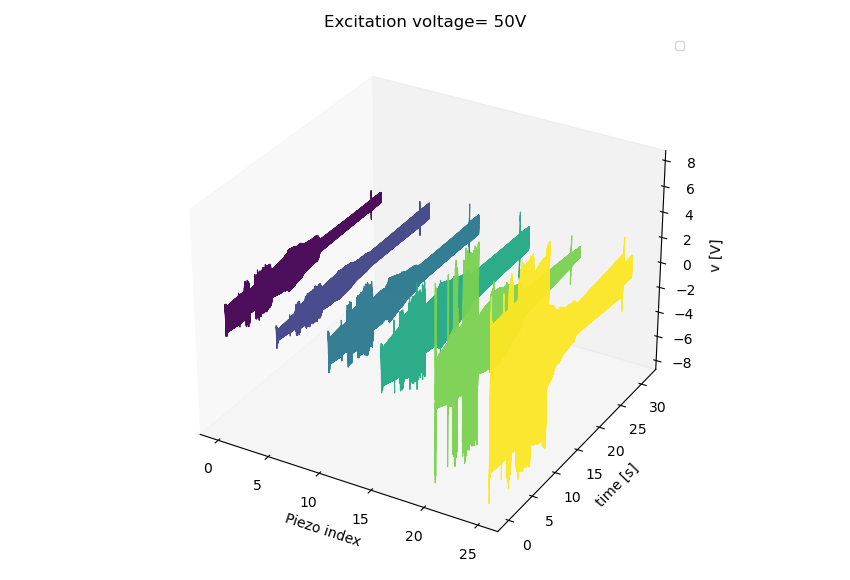

In [75]:
%matplotlib widget 
# =========================
# Phase portraits for each piezo state pair
# =========================

fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111, projection='3d')
ampidx = 3
r = results_amp[ampidx]

indices = [0, 5, 10, 15, 20 , 25]
colors = plt.cm.viridis(np.linspace(0, 1, len(indices) ))
n_periods_keep = 100000
t_inds_keep = n_periods_keep * 100
f0 = 2900
f = 3200
for i, (idx, z, v) in enumerate(zip(indices,r["z"][indices,:], r["v"][indices,:])):
    f_inst_theory = f0 + (f - f0) * r['t'] / r['t'][-1]  
    # ax.plot(np.ones_like(z)*idx, f_inst_theory, v, color=colors[i], lw=0.8, alpha=0.95)
    ax.plot(np.ones_like(z)*idx, r['t'], v, color=colors[i], lw=0.8, alpha=0.95)

ax.set_xlabel('Piezo index')
ax.set_xticks(indices)
ax.set_ylabel('time [s]')
ax.set_zlabel('v [V]')
ax.set_title(f'Excitation voltage= {amps[ampidx]:.0f}V')
ax.grid(False )
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()


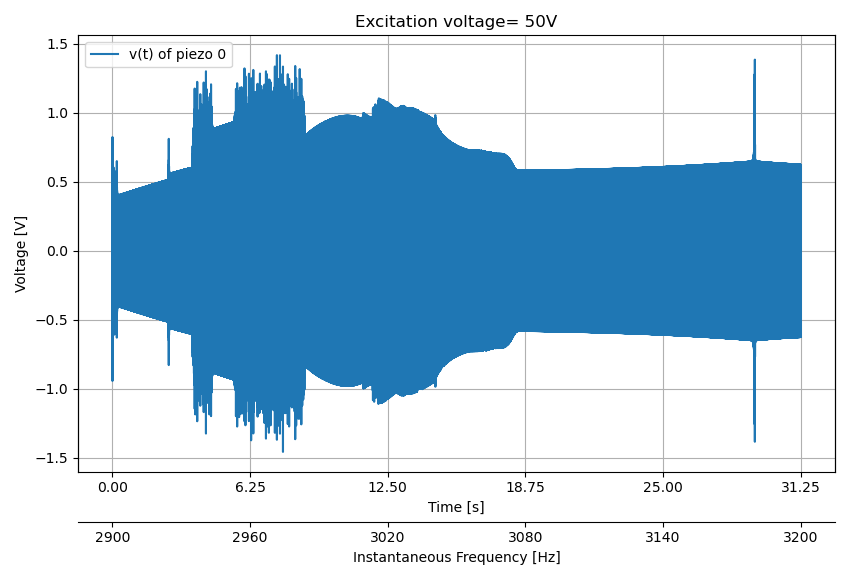

In [100]:
ampidx = 3
fig, ax = plt.subplots(figsize=(8.5, 5.8))
r = results_amp[ampidx]
ax.plot(r["t"], r["v"][5, :], label='v(t) of piezo 0')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Voltage [V]')
ax.set_title(f'Excitation voltage= {amps[ampidx]:.0f}V')
ax.grid(True)
f0 = 2900
f = 3200
f_inst_theory = f0 + (f - f0) * r["t"] / r["t"][-1]
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
t_ticks = np.linspace(r["t"][0], r["t"][-1], 6)
ax.set_xticks(t_ticks)
ax_top.set_xticks(t_ticks)
ax_top.set_xticklabels([f'{f0 + (f - f0) * t / r["t"][-1]:.0f}' for t in t_ticks])
ax_top.xaxis.set_ticks_position('bottom')
ax_top.xaxis.set_label_position('bottom')
ax_top.spines['bottom'].set_position(('outward', 36))
ax_top.spines['top'].set_visible(False)
ax_top.set_xlabel('Instantaneous Frequency [Hz]')
ax.legend()
fig.tight_layout()
plt.show()

In [16]:
stop

NameError: name 'stop' is not defined

In [ ]:
# Freq sweep 
freqs = np.linspace(2955, 2980, 20)
def single_simulation(f):
    amp = 50
    f0 = 500
    n_periods_total = 10000
    n_periods_keep = 1
    points_per_period = 100
    T = 1 / f
    dt = T / points_per_period
    t_end  = n_periods_total * T
    t_eval = np.arange(0, t_end, dt)
    def v_exc(t):
        t1 = t_end / 10
        t = np.asarray(t)
        out = 50 * np.cos(2 * np.pi * f * t)
        out = np.where(t < t1, 50 * chirp(t, f0=f0, f1=f, t1=t1, method="linear"), out)
        return out

    # def v_exc(t):
    #     return amp * chirp(t, f0=0, f1=f, t1=t_end, method="linear")

    out = rom.run_time_sim(
        v_exc=v_exc,
        j_exc=30,
        R_c=R_c,
        K_p=K_p,
        K_i=K_i,
        K_c=K_c,
        t_end=t_end,
        t_eval=t_eval,
        x_eval=x_eval,
        rtol=rtol,
        atol=atol,
    )

    # Mechanical modal coordinates are the first rom.N entries of x(t).
    eta = out["eta"]
    eta_dot = out["eta_dot"]
    z = out["z"]
    v = out["v"]

    t = out["t"]

    strobe = stroboscopic_sample_x_and_xdot(t, eta, eta_dot, z, v, points_per_period, n_periods_keep)

    result = {
        "f": f,
        "t": t,
        "veloc": out["veloc"],
        "eta": eta,
        "eta_dot": eta_dot,
        "z": z,
        "v": v,
        "freq": out["freq"],
        "FRF": out["FRF"],
        "Y": out["Y"],
    }
    result.update(strobe)

    return result   

results_freq = Parallel(n_jobs=len(freqs), verbose=12)(
    delayed(single_simulation)(f) for f in freqs
)

[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   3 out of  20 | elapsed:  4.6min remaining: 26.1min
[Parallel(n_jobs=20)]: Done   5 out of  20 | elapsed:  4.7min remaining: 14.0min
[Parallel(n_jobs=20)]: Done   7 out of  20 | elapsed:  4.7min remaining:  8.8min
[Parallel(n_jobs=20)]: Done   9 out of  20 | elapsed:  4.8min remaining:  5.9min
[Parallel(n_jobs=20)]: Done  11 out of  20 | elapsed:  4.9min remaining:  4.0min
[Parallel(n_jobs=20)]: Done  13 out of  20 | elapsed:  5.0min remaining:  2.7min
[Parallel(n_jobs=20)]: Done  15 out of  20 | elapsed:  5.0min remaining:  1.7min
[Parallel(n_jobs=20)]: Done  17 out of  20 | elapsed:  5.1min remaining:   53.8s
[Parallel(n_jobs=20)]: Done  20 out of  20 | elapsed:  5.2min finished


In [ ]:
results[-1]["Y"].shape
results[-1]["freq"].shape


(250001,)

KeyError: 'amp'

<Figure size 800x500 with 0 Axes>

In [ ]:
r['z'][indices,:].shape 

(200000,)
(200000,)
(200000,)
(200000,)
(200000,)
(200000,)


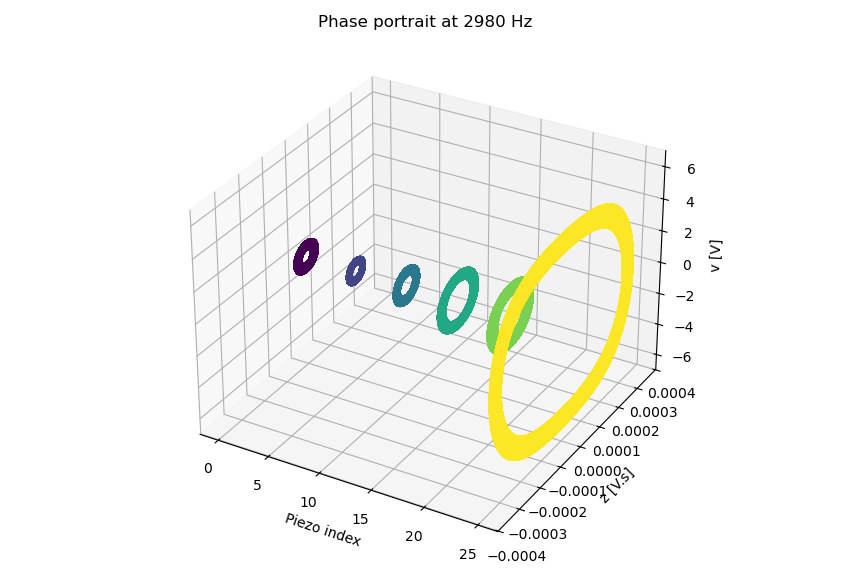

In [79]:
# =========================
# Phase portraits for each piezo state pair
# =========================

fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111, projection='3d')
fidx = -1
r = results_freq[fidx]
n_periods_total = 10000
n_periods_keep = 1000
points_per_period = 100
indices = [0, 5, 10, 15, 20 , 25]
colors = plt.cm.viridis(np.linspace(0, 1, len(indices) ))
n_periods_keep = 2000
t_inds_keep = n_periods_keep * points_per_period
for i, (idx, z, v) in enumerate(zip(indices,r["z"][indices,-t_inds_keep:], r["v"][indices,-t_inds_keep:])):
    print(z.shape )
    ax.scatter(np.ones_like(z)*idx, z, v,s=1, color=colors[i], lw=1.2, alpha=0.95)

ax.set_xlabel('Piezo index')
ax.set_xticks(indices)
ax.set_zlabel('v [V]')
ax.set_ylabel('z [V.s]')
ax.set_title(f'Phase portrait at {freqs[fidx]:.0f} Hz')
ax.grid(True)
# ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

Saved animation to piezos.gif


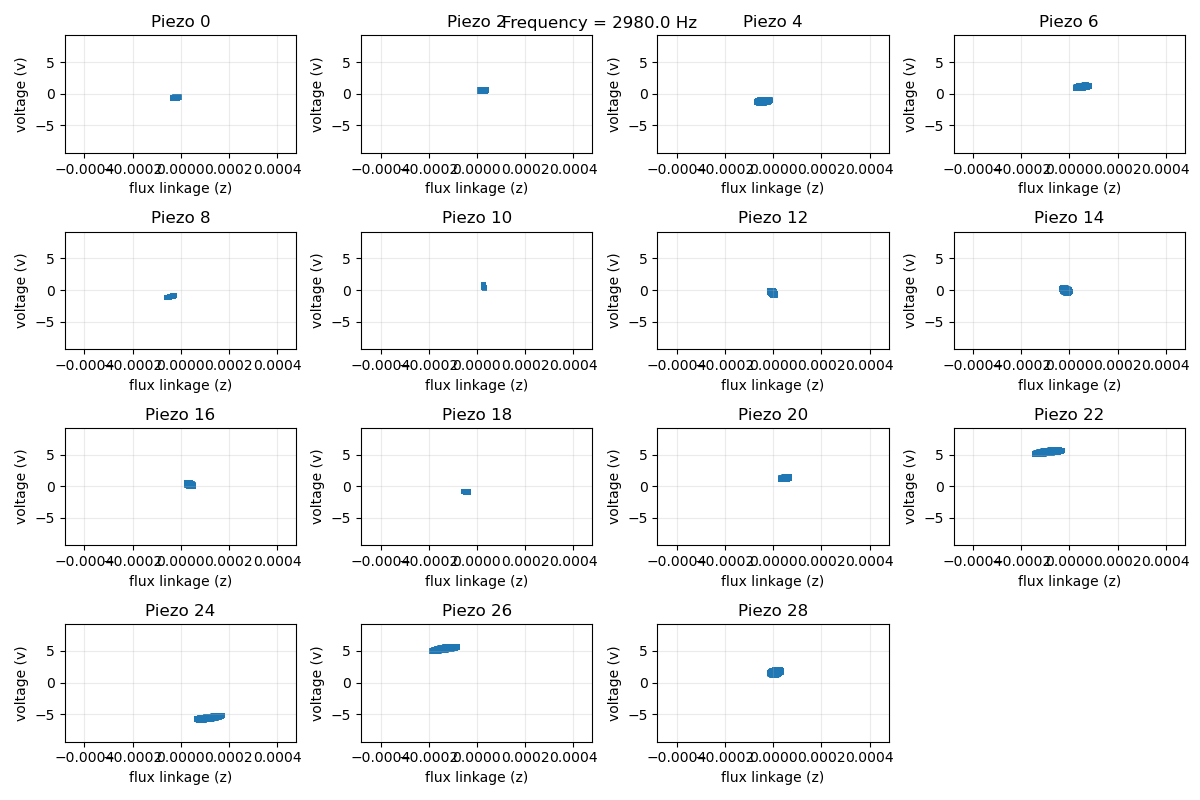

In [ ]:
# Animated grid of 2D phase portraits for selected piezos over frequencies
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from math import ceil
from pathlib import Path

def animate_piezos_grid(piezo_indices, freq_indices=None, freqs=None, results_list=None, ncols=4, figsize=(12,8), interval=500, save_path=None, fps=None):
    # pick results source
    results = results_list if results_list is not None else globals().get('results_freq', None)
    if results is None:
        results = globals().get('results_amp', None)
    if results is None:
        raise RuntimeError('No `results_freq` or `results_amp` found in workspace')

    # build freq->result mapping (results_freq items have key 'f')
    freq_map = {}
    avail = []
    for r in results:
        f = r.get('f') or float(r.get('freq') if np.isscalar(r.get('freq', None)) else (r.get('f', np.nan)))
        if f is None:
            continue
        freq_map[float(f)] = r
        avail.append(float(f))
    avail = sorted(set(avail))

    # choose frames: default = all frequencies; otherwise use indices or explicit frequencies
    if freq_indices is not None:
        frames_freq = [avail[i] for i in freq_indices if 0 <= i < len(avail)]
    elif freqs is not None:
        frames_freq = []
        for fq in freqs:
            nearest = min(avail, key=lambda a: abs(a - fq))
            if nearest not in frames_freq:
                frames_freq.append(nearest)
    else:
        frames_freq = avail

    frames = [freq_map[f] for f in frames_freq]

    def _as_2d_series(arr, pidx):
        arr = np.asarray(arr)
        if arr.ndim == 2:
            return arr[pidx] if pidx < arr.shape[0] else arr.ravel()
        return arr.ravel()

    all_z = []
    all_v = []
    for r in frames:
        z_all = r.get('z_poincare', r.get('z'))
        v_all = r.get('v_poincare', r.get('v'))
        for pidx in piezo_indices:
            z = _as_2d_series(z_all, pidx)
            v = _as_2d_series(v_all, pidx)
            all_z.append(np.asarray(z).ravel())
            all_v.append(np.asarray(v).ravel())
    z_all = np.concatenate(all_z) if all_z else np.array([0.0, 1.0])
    v_all = np.concatenate(all_v) if all_v else np.array([0.0, 1.0])
    z_pad = 0.05 * (np.nanmax(z_all) - np.nanmin(z_all) + 1e-12)
    v_pad = 0.05 * (np.nanmax(v_all) - np.nanmin(v_all) + 1e-12)

    n = len(piezo_indices)
    nrows = ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).flatten()

    scatters = []
    for i, pidx in enumerate(piezo_indices):
        ax = axes[i]
        ax.set_xlabel('flux linkage (z)')
        ax.set_ylabel('voltage (v)')
        ax.set_title(f'Piezo {pidx}')
        ax.set_xlim(np.nanmin(z_all) - z_pad, np.nanmax(z_all) + z_pad)
        ax.set_ylim(np.nanmin(v_all) - v_pad, np.nanmax(v_all) + v_pad)
        ax.grid(True, alpha=0.25)
        sc = ax.scatter([], [], s=6)
        scatters.append(sc)
    # turn off unused axes
    for j in range(n, len(axes)):
        axes[j].axis('off')

    def update(frame_i):
        r = frames[frame_i]
        for sc_i, pidx in enumerate(piezo_indices):
            # prefer poincare arrays if present
            z_all = r.get('z_poincare', r.get('z'))
            v_all = r.get('v_poincare', r.get('v'))
            try:
                z = _as_2d_series(z_all, pidx)
                v = _as_2d_series(v_all, pidx)
            except Exception:
                z = np.asarray(z_all).ravel()
                v = np.asarray(v_all).ravel()
            pts = np.column_stack([z, v])
            scatters[sc_i].set_offsets(pts)
        fig.suptitle(f'Frequency = {frames_freq[frame_i]:.1f} Hz')
        return scatters

    anim = FuncAnimation(fig, update, frames=len(frames), interval=interval, blit=False, repeat=True)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        fps = fps or max(1, int(round(1000 / interval)))
        if save_path.suffix.lower() == '.gif':
            anim.save(str(save_path), writer='pillow', fps=fps)
        else:
            try:
                anim.save(str(save_path), writer='ffmpeg', fps=fps)
            except Exception:
                fallback = save_path.with_suffix('.gif')
                anim.save(str(fallback), writer='pillow', fps=fps)
                save_path = fallback
        print(f'Saved animation to {save_path}')

    return anim

# Example usage (uncomment to run):
# anim = animate_piezos_grid([0,5,10,15], freq_indices=[0, 2, 4, 6], ncols=2, interval=400, save_path='piezos.gif')
anim = animate_piezos_grid([0,2, 4, 6, 8, 10, 12, 16, 20, 24, 28], save_path='piezos.gif')  # uses all available frequencies by default
from IPython.display import HTML
# HTML(anim.to_jshtml())

C:\Users\setemadi3\AppData\Local\Temp\ipykernel_40732\511501609.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=8, ncol=2)


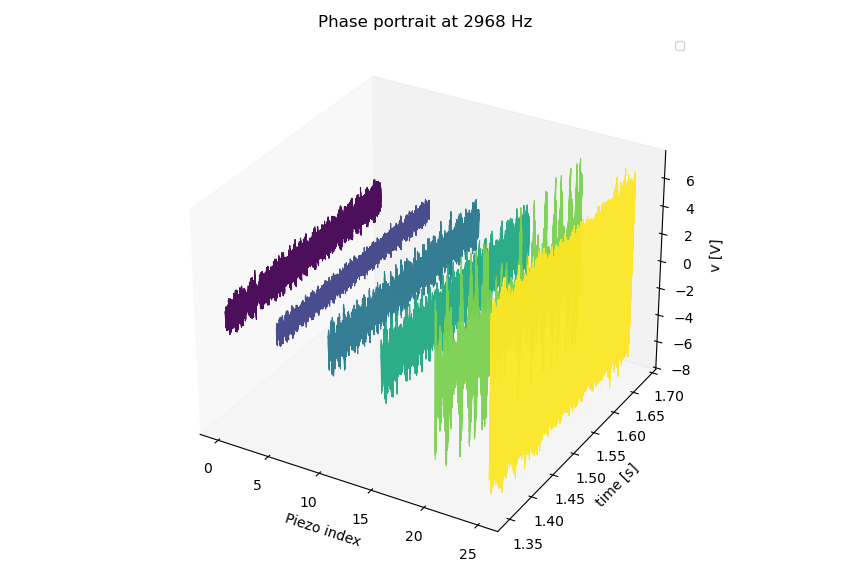

In [30]:
# =========================
# Phase portraits for each piezo state pair
# =========================

fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111, projection='3d')
r = results_freq[fidx]

indices = [0, 5, 10, 15, 20 , 25]
colors = plt.cm.viridis(np.linspace(0, 1, len(indices) ))
n_periods_keep = 1000
t_inds_keep = n_periods_keep * points_per_period
for i, (idx, z, v) in enumerate(zip(indices,r["z"][indices,-t_inds_keep:], r["v"][indices,-t_inds_keep:])):
    ax.plot(np.ones_like(z)*idx, r['t'][-t_inds_keep:], v, color=colors[i], lw=0.8, alpha=0.95)

ax.set_xlabel('Piezo index')
ax.set_xticks(indices)
ax.set_ylabel('time [s]')
ax.set_zlabel('v [V]')
ax.set_title(f'Phase portrait at {freqs[fidx]:.0f} Hz')
ax.grid(False )
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

C:\Users\setemadi3\AppData\Local\Temp\ipykernel_40732\1105244861.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=8, ncol=2)


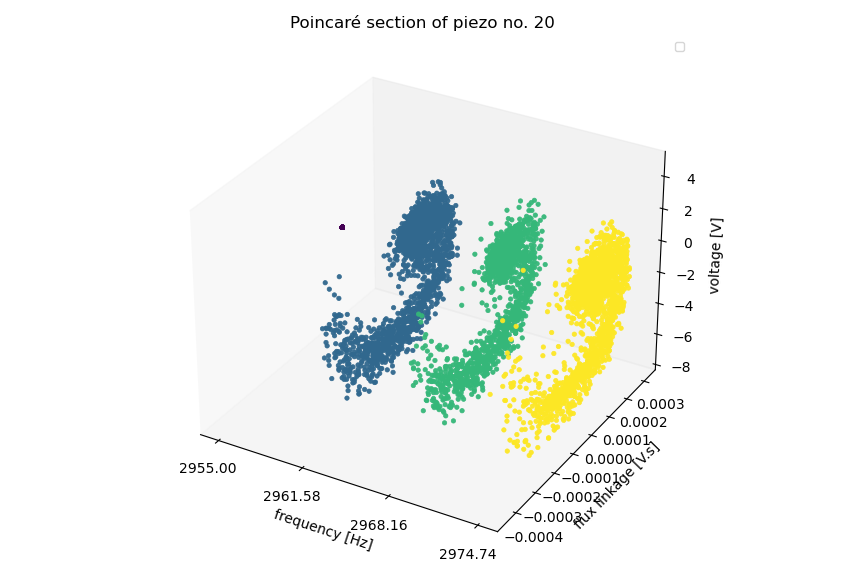

In [83]:
# =========================
# Phase portraits for each piezo state pair
# =========================

fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111, projection='3d')
r = results_freq[fidx]

indices = [20]
freq_slice = slice(0, None, 5)
colors = plt.cm.viridis(np.linspace(0, 1, len(results_freq[freq_slice]) ))
n_periods_keep = 1000
t_inds_keep = n_periods_keep * points_per_period
for j, r in enumerate(results_freq[freq_slice]):
    for i, (idx, z, v) in enumerate(zip(indices,r["z_poincare"][indices,-t_inds_keep:], r["v_poincare"][indices,-t_inds_keep:])):
        ax.scatter(np.ones_like(z)*r['f'], z, v, color=colors[j], s=10, lw=0.5, alpha=0.95)

ax.set_xlabel('frequency [Hz]')
ax.set_xticks([r['f'] for j, r in enumerate(results_freq[freq_slice])])
ax.set_zlabel('voltage [V]')
ax.set_ylabel('flux linkage [V.s]')
ax.set_title(f'Poincaré section of piezo no. {indices[0]:.0f} ')
ax.grid(False )
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

C:\Users\setemadi3\AppData\Local\Temp\ipykernel_40732\2338139565.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=8, ncol=2)


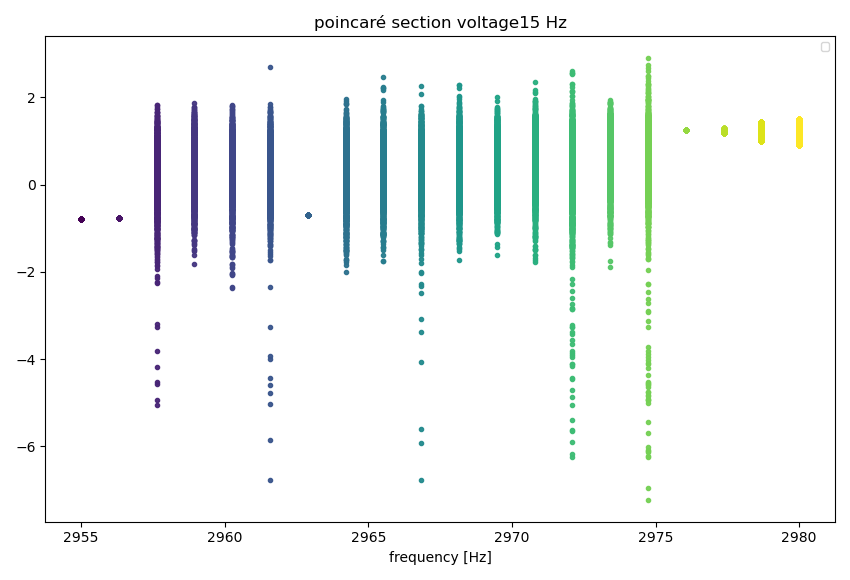

In [57]:
# =========================
# Phase portraits for each piezo state pair
# =========================

fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111,)
r = results_freq[fidx]

indices = [15]
colors = plt.cm.viridis(np.linspace(0, 1, len(results_freq) ))
n_periods_keep = 1000
t_inds_keep = n_periods_keep * points_per_period
for j, r in enumerate(results_freq):
    ax.plot(r['f']*np.ones_like(r['v_poincare'][indices[0],:]), r['v_poincare'][indices[0],:], '.', color=colors[j], lw=0.8, alpha=0.95)
ax.set_xlabel('frequency [Hz]')
# ax.set_xticks([j for j, r in enumerate(results_freq)])
# ax.set_zlabel('v [V]')
ax.set_title(f'poincaré section voltage {indices[0]:.0f} Hz')
ax.grid(False )
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

C:\Users\setemadi3\AppData\Local\Temp\ipykernel_40732\4176645444.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=8, ncol=2)


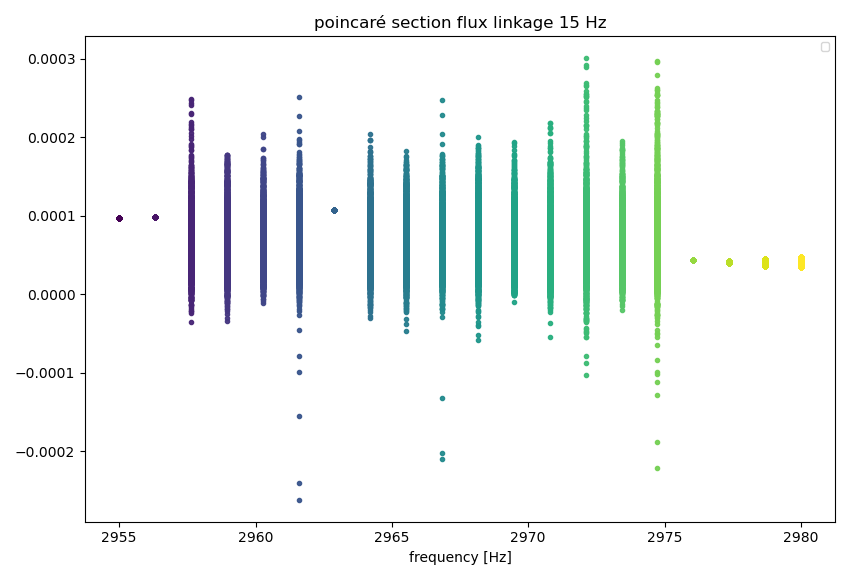

In [58]:
# =========================
# Phase portraits for each piezo state pair
# =========================

fig = plt.figure(figsize=(8.5, 5.8))
ax = fig.add_subplot(111,)
r = results_freq[fidx]

indices = [15]
colors = plt.cm.viridis(np.linspace(0, 1, len(results_freq) ))
n_periods_keep = 1000
t_inds_keep = n_periods_keep * points_per_period
for j, r in enumerate(results_freq):
    ax.plot(r['f']*np.ones_like(r['v_poincare'][indices[0],:]), r['z_poincare'][indices[0],:], '.', color=colors[j], lw=0.8, alpha=0.95)
ax.set_xlabel('frequency [Hz]')
# ax.set_xticks([j for j, r in enumerate(results_freq)])
# ax.set_zlabel('v [V]')
ax.set_title(f'poincaré section flux linkage {indices[0]:.0f} Hz')
ax.grid(False )
ax.legend(loc='best', fontsize=8, ncol=2)
fig.tight_layout()
plt.show()